In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm import tqdm
import numpy as np
import cv2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer

import torch
import torchvision.transforms.v2 as v2
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchmetrics as tm

In [ ]:
root_path = "/home/stefan/ioai-prep/kits/ceoai_mock/astral"
device = "cuda" if torch.cuda.is_available() else "cpu"

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

batch_size = 32

# Data

In [3]:
train_df = pd.read_csv(f"{root_path}/train.csv")
test_df = pd.read_csv(f"{root_path}/test_solution.csv")

train_df.head()

,image_id,fried_parameter,airmass,target_flux,star_center_x,star_center_y
0,00000.png,0.211573,1.074476,107.303039,57,69
1,00001.png,0.154609,1.549914,1319.026177,64,67
2,00002.png,0.225962,1.154836,56.081752,67,58
3,00003.png,0.198553,1.182792,376.145959,71,65
4,00004.png,0.096010,1.758739,9128.635160,64,71


In [4]:
target_scaler = FunctionTransformer(func=np.log1p, inverse_func=np.expm1).fit(
    train_df[["target_flux"]]
)

train_flux = target_scaler.transform(train_df[["target_flux"]].values)
target_scaler_2nd = StandardScaler().fit(train_flux)

features_scaler = StandardScaler().fit(train_df[["fried_parameter", "airmass"]])

(array([669.,  99.,  68.,  45.,  32.,  37.,  24.,  12.,  11.,   3.]),
 array([   30.59567702,  2626.44829723,  5222.30091743,  7818.15353764,
        10414.00615785, 13009.85877805, 15605.71139826, 18201.56401847,
        20797.41663867, 23393.26925888, 25989.12187909]),
 <BarContainer object of 10 artists>)

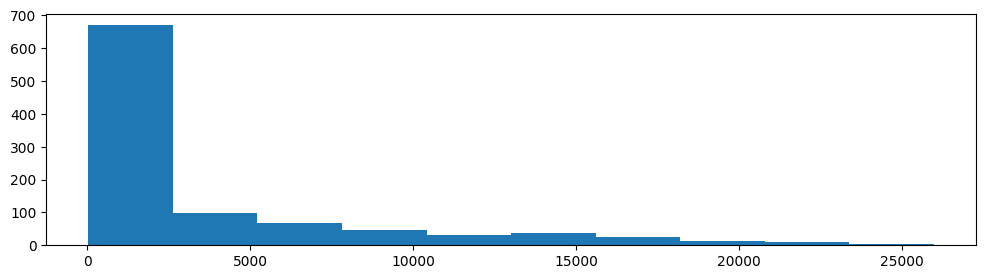

In [5]:
plt.figure(figsize=(12,3))
plt.hist(train_df["target_flux"])

In [ ]:
1/0

In [6]:
class AstralDataset(Dataset):
    def __init__(self, df, transform, is_train=False):
        self.df = df
        self.transform = transform
        self.is_train = is_train

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = f"{root_path}/{'train' if self.is_train else 'test'}_images/{row['image_id']}"
        image = Image.open(img_path).convert("L")
        image = self.transform(image)

        if self.is_train:
            row_df = self.df.iloc[[idx]] # standard scaler wants an array of rows
            tabular_features = features_scaler.transform(
                row_df[["fried_parameter", "airmass"]]
            )
            tabular_features = torch.tensor(tabular_features, dtype=torch.float32).squeeze()

            target = target_scaler.transform(row_df[["target_flux"]]).values
            target = target_scaler_2nd.transform(target)
            target = torch.tensor(target, dtype=torch.float32).squeeze()

            return image, tabular_features, target

        return image

    def __len__(self):
        return len(self.df)

In [7]:
train_transform = v2.Compose([
    v2.RandomHorizontalFlip(),
    v2.RandomVerticalFlip(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])

train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=seed)

train_ds = AstralDataset(train_df, train_transform, is_train=True)
val_ds = AstralDataset(val_df, transform, is_train=True)
test_ds = AstralDataset(test_df, transform)

test_ds_sub1 = AstralDataset(test_df, v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
]))

train_loader = DataLoader(train_ds, batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size)
test_loader = DataLoader(test_ds, batch_size)

In [8]:
batch = next(iter(train_loader))
[b.shape for b in batch]

[torch.Size([32, 1, 128, 128]), torch.Size([32, 2]), torch.Size([32])]

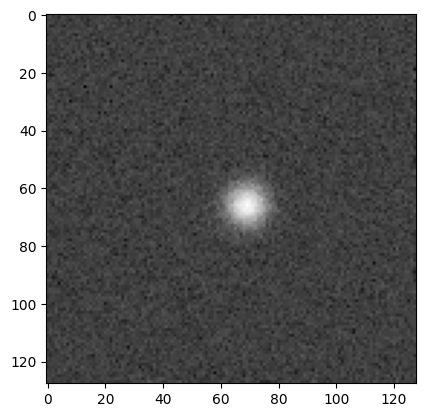

In [9]:
sample_idx = 1
sample_img = batch[0][sample_idx].permute(1, 2, 0)
plt.imshow(sample_img, cmap='gray')

# Subtask 1

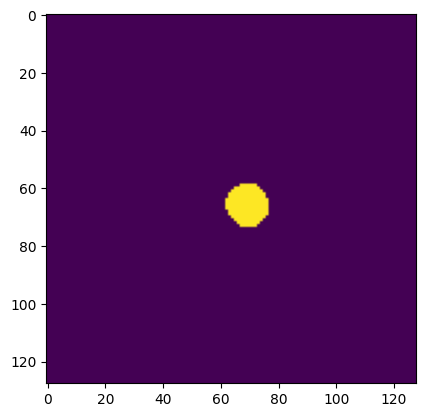

In [10]:
sample_img = batch[0][sample_idx].permute(1, 2, 0).numpy()

blurred = cv2.medianBlur(sample_img, ksize=5)
_, thresh = cv2.threshold(blurred, thresh=0.2, maxval=1, type=cv2.THRESH_BINARY)
plt.imshow(thresh)

In [11]:
thresh_uint8 = (thresh * 255).astype(np.uint8)

contours, hierarchy = cv2.findContours(
    thresh_uint8, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
)

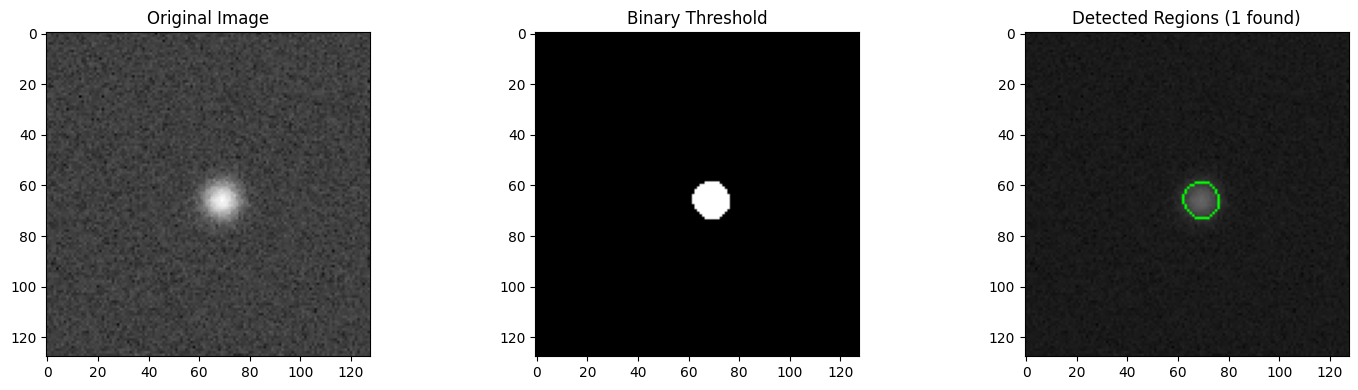

In [12]:
# convert grayscale to BGR for colored contours
display = cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
cv2.drawContours(display, contours, -1, (0, 255, 0), 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Original Image")
axes[1].imshow(thresh, cmap="gray")
axes[1].set_title("Binary Threshold")
axes[2].imshow(display)
axes[2].set_title(f"Detected Regions ({len(contours)} found)")
plt.tight_layout()
plt.show()

In [13]:
contours = sorted(contours, key=cv2.contourArea, reverse=True)
biggest_contour = contours[0] if contours else None
x, y, w, h = cv2.boundingRect(biggest_contour)

center = (int(x+w/2), int(y+h/2))
center

(69, 66)

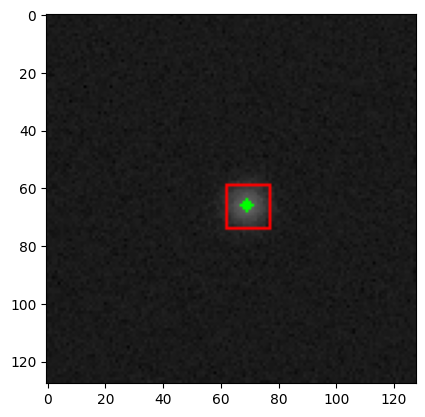

In [14]:
display = cv2.cvtColor((sample_img * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)
cv2.rectangle(display, (x, y), (x + w, y + h), (255, 0, 0), 1)
cv2.circle(display, center, radius=2, color=(0, 255, 0), thickness=-1)
plt.imshow(display)

In [ ]:
1/0

In [15]:
def get_star_center(img, thresh_val=0.15):
    img = img.permute(1, 2, 0).numpy()

    blurred = cv2.medianBlur(img, ksize=5)
    _, thresh = cv2.threshold(blurred, thresh=thresh_val, maxval=1, type=cv2.THRESH_BINARY)
    thresh_uint8 = (thresh * 255).astype(np.uint8)

    contours, _ = cv2.findContours(
        thresh_uint8, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
    )

    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    biggest_contour = contours[0] if contours else None
    if biggest_contour is not None:
        x, y, w, h = cv2.boundingRect(biggest_contour)
        center = (x + w / 2, y + h / 2)
        return center
    return (128/2, 128/2)


get_star_center(batch[0][sample_idx])

(69.5, 66.5)

In [16]:
def solve_subtask1(thresh_val=0.2):
    subtask1 = []

    for test_img in tqdm(test_ds_sub1):
        subtask1.append(get_star_center(test_img, thresh_val))

    return (
        sum([s == (128 / 2, 128 / 2) for s in subtask1]) / len(subtask1) * 100,
        subtask1,
    )

In [17]:
percentage, subtask1 = solve_subtask1(thresh_val=0.2)
f"{(percentage):.2f}% missing"

100%|██████████| 300/300 [00:00<00:00, 1108.80it/s]


'59.67% missing'

# Subtask 2

## Teacher Model

In [ ]:
class FiLMBlock(nn.Module):
    def __init__(self, channels, meta_dim=2):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(meta_dim, 32), nn.ReLU(), nn.Linear(32, channels * 2)
        )

    def forward(self, x, meta):
        params = self.gen(meta).unsqueeze(-1).unsqueeze(-1)
        gamma, beta = torch.split(params, params.size(1) // 2, dim=1)
        return x * (1 + gamma) + beta


class AstroBlock(nn.Module):
    """Residual block with FiLM modulation."""

    def __init__(self, in_c, out_c, stride=1, use_film=True):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_c)
        self.conv2 = nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_c)
        self.film = FiLMBlock(out_c) if use_film else nn.Identity()

        self.shortcut = nn.Sequential()
        if stride != 1 or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, 1, stride, bias=False), nn.BatchNorm2d(out_c)
            )

    def forward(self, x, meta=None):
        out = F.relu(self.bn1(self.conv1(x)))
        if meta is not None:
            out = self.film(out, meta)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class TeacherNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Conv2d(1, 32, 3, 1, 1, bias=False)
        self.bn_stem = nn.BatchNorm2d(32)

        self.layer1 = AstroBlock(32, 64, stride=1)
        self.layer2 = AstroBlock(64, 128, stride=2)
        self.layer3 = AstroBlock(128, 256, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(256 + 2, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, img, meta):
        x = F.relu(self.bn_stem(self.stem(img)))
        f1 = self.layer1(x, meta)
        f2 = self.layer2(f1, meta)
        f3 = self.layer3(f2, meta)

        pooled = self.pool(f3).view(f3.size(0), -1)
        out = self.fc(torch.cat([pooled, meta], dim=1)).squeeze(-1)
        return out, [f1, f2, f3]

In [ ]:
teacher = TeacherNet().to(device)

sample_img = batch[0].to(device)
sample_tab = batch[1].to(device)

teacher(sample_img, sample_tab)[0].shape

torch.Size([32])

## Training teacher 

In [ ]:
lr = 2e-4
epochs = 200
best_loss = float("inf")

criterion = nn.HuberLoss(delta=1.0)
optimizer = optim.AdamW(teacher.parameters(), lr, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs*len(train_loader), eta_min=1e-6)

val_rmse = tm.MeanSquaredError(squared=False).to(device)
train_rmse = tm.MeanSquaredError(squared=False).to(device)

In [21]:
denormalize = lambda x: torch.expm1(
    x * target_scaler_2nd.scale_[0] + target_scaler_2nd.mean_[0]
)

In [ ]:
for epoch in range(1, epochs + 1):
    teacher.train()
    train_rmse.reset()
    for img, tab, target in (train_loader):
        img, tab, target = img.to(device), tab.to(device), target.to(device)

        out, _ = teacher(img, tab)
        loss = criterion(out, target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_rmse(denormalize(out), denormalize(target))

    teacher.eval()
    val_rmse.reset()
    for img, tab, target in val_loader:
        img, tab, target = img.to(device), tab.to(device), target.to(device)

        with torch.no_grad():
            out, _ = teacher(img, tab)

        val_rmse(denormalize(out), denormalize(target))

    v_rmse = val_rmse.compute().item()
    if v_rmse < best_loss:
        best_loss = v_rmse
        torch.save(teacher.state_dict(), "teacher.pth")
        print(f"new best! val_rmse={v_rmse:.3f}")
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: train={train_rmse.compute():.3f}, val={v_rmse:.3f}")

new best! val_rmse=6512.642
new best! val_rmse=4416.721
new best! val_rmse=2931.560
new best! val_rmse=1226.953
new best! val_rmse=971.912
Epoch 20: train=2660.939, val=1005.646
new best! val_rmse=939.895
new best! val_rmse=816.561
new best! val_rmse=509.542
Epoch 40: train=1551.526, val=1768.313
new best! val_rmse=508.581
Epoch 60: train=963.291, val=579.729
new best! val_rmse=433.468
new best! val_rmse=379.953
new best! val_rmse=324.590
Epoch 80: train=834.850, val=1040.513
new best! val_rmse=291.002
Epoch 100: train=674.578, val=896.574
Epoch 120: train=441.195, val=731.235
new best! val_rmse=230.788
new best! val_rmse=229.680
Epoch 140: train=347.091, val=229.680
Epoch 160: train=318.752, val=245.360
new best! val_rmse=223.774
Epoch 180: train=312.100, val=241.916
Epoch 200: train=368.236, val=253.695


In [23]:
teacher.load_state_dict(torch.load("teacher.pth"))

<All keys matched successfully>

## Student model

In [ ]:
class StudentNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.stem = nn.Conv2d(1, 32, 3, 1, 1, bias=False)
        self.bn_stem = nn.BatchNorm2d(32)

        self.layer1 = AstroBlock(32, 64, stride=1, use_film=False)
        self.layer2 = AstroBlock(64, 128, stride=2, use_film=False)
        self.layer3 = AstroBlock(128, 256, stride=2, use_film=False)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, img):
        x = F.relu(self.bn_stem(self.stem(img)))
        f1 = self.layer1(x)
        f2 = self.layer2(f1)
        f3 = self.layer3(f2)

        pooled = self.pool(f3).view(f3.size(0), -1)
        out = self.fc(pooled).squeeze(-1)
        return out, [f1, f2, f3]

In [45]:
student = StudentNet().to(device)

## Student training

In [ ]:
best_student_loss = float("inf")

def train_student(alpha=0.7, epochs=100, lr=1e-3):
    global best_student_loss
    student = StudentNet().to(device)

    criterion_task = nn.HuberLoss(delta=1.0)
    criterion_distill = nn.MSELoss()

    optimizer = optim.AdamW(student.parameters(), lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs * len(train_loader)
    )

    val_rmse_s = tm.MeanSquaredError(squared=False).to(device)
    teacher.eval()

    for epoch in range(1, epochs + 1):
        student.train()
        for img, tab, target in tqdm(train_loader):
            img, tab, target = img.to(device), tab.to(device), target.to(device)

            with torch.no_grad():
                _, t_feats = teacher(img, tab)

            s_out, s_feats = student(img)

            loss_task = criterion_task(s_out, target)

            loss_feat = sum(criterion_distill(s, t) for s, t in zip(s_feats, t_feats))

            loss = loss_task + alpha * loss_feat

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

        student.eval()
        val_rmse_s.reset()
        for img, _, target in val_loader:
            img, target = img.to(device), target.to(device)
            with torch.no_grad():
                s_out, _ = student(img)
            val_rmse_s(denormalize(s_out), denormalize(target))

        v_rmse = val_rmse_s.compute().item()
        if v_rmse < best_student_loss:
            best_student_loss = v_rmse
            torch.save(student.state_dict(), "student.pth")
            print(f"New best: {v_rmse:.3f}")

        print(f"Epoch {epoch}: val_rmse={v_rmse:.3f}")

In [ ]:
train_student(alpha=0.7)

100%|██████████| 25/25 [00:02<00:00, 11.36it/s]


New best: 6803.820
Epoch 1: val_rmse=6803.820


100%|██████████| 25/25 [00:02<00:00, 11.37it/s]


New best: 6296.667
Epoch 2: val_rmse=6296.667


100%|██████████| 25/25 [00:02<00:00, 11.74it/s]


...

Epoch 98: val_rmse=354.429


100%|██████████| 25/25 [00:02<00:00, 11.73it/s]


Epoch 99: val_rmse=317.484


100%|██████████| 25/25 [00:02<00:00, 11.76it/s]


Epoch 100: val_rmse=320.706


In [48]:
student.load_state_dict(torch.load("student.pth"))

<All keys matched successfully>

## Inference

In [ ]:
def tta_inference(model, img_batch, device="cuda"):
    predictions = []
    img_batch = img_batch.to(device)
    for f in [None, [-1], [-2], [-2, -1]]:
        curr = img_batch if f is None else torch.flip(img_batch, f)
        with torch.no_grad():
            out, _ = model(curr)
        predictions.append(out)
    return torch.stack(predictions).mean(dim=0)

In [50]:
subtask2 = []
student.eval()
for img in tqdm(test_loader):
    out = tta_inference(student, img, device=device).unsqueeze(-1)
    subtask2.extend(out.cpu().tolist())

subtask2 = target_scaler.inverse_transform(
    target_scaler_2nd.inverse_transform(subtask2)
).ravel()

100%|██████████| 10/10 [00:00<00:00, 13.99it/s]


# Submission

In [51]:
def build_subtask(sid, answers):
    return pd.DataFrame({
        "subtaskID": sid,
        "datapointID": test_df["image_id"],
        "answer": answers
    })

subtasks = [
    (1, subtask1),
    (2, subtask2)
]

submission = pd.concat([build_subtask(sid, answers) for sid, answers in subtasks])
submission.head()

,subtaskID,datapointID,answer
0,1,00000.png,"(73.0, 64.0)"
1,1,00001.png,"(64.0, 64.0)"
2,1,00002.png,"(64.0, 64.0)"
3,1,00003.png,"(64.0, 64.0)"
4,1,00004.png,"(64.0, 64.0)"


In [52]:
submission.to_csv("submission.csv", index=False)